In [3]:
# Cell 1 — Install & Import
%pip install -q pandas openpyxl numpy statsmodels arch matplotlib

import pandas as pd
import numpy as np
import statsmodels.api as sm
from arch import arch_model
import matplotlib.pyplot as plt
import warnings
from datetime import date

warnings.filterwarnings('ignore')

In [4]:
# Cell 2 — Mount Google Drive & Load Data
from google.colab import drive
drive.mount('/content/drive')

# === USER: Update this path to your Stock_Indices.xlsx location ===
DATA_PATH = '/content/drive/MyDrive/data/data_full.xlsx'

dic_df = pd.read_excel(DATA_PATH, sheet_name=None, header=0, usecols=['Date', 'Price', 'Change %'])

for sheet, df in dic_df.items():
    df['Date'] = pd.to_datetime(df['Date'])
    df['Price'] = pd.to_numeric(df['Price'], errors='coerce')
    df['Change %'] = pd.to_numeric(
        df['Change %'].astype(str).str.replace('%', '', regex=False).str.strip(),
        errors='coerce'
    )
    df = df.set_index('Date')
    df.index = df.index.date
    df = df.sort_index()
    dic_df[sheet] = df

print(f"Sheets loaded: {list(dic_df.keys())}")
for sheet, df in dic_df.items():
    print(f"  {sheet}: shape={df.shape}, range={df.index.min()} to {df.index.max()}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Sheets loaded: ['VNI', 'BSE', 'IGPA', 'TWSE', 'FTSE', 'CAC', 'KOSPI', 'Sing', 'BYMA', 'SET', 'Dow', 'S&P500', 'SZSE', 'Shang', 'SSE', 'MIWD00000PUS', 'MIWO00000PUS', 'MSCINA', 'MSCIFE', 'MSCIEU']
  VNI: shape=(2298, 2), range=2017-01-03 to 2026-03-20
  BSE: shape=(2285, 2), range=2017-01-02 to 2026-03-20
  IGPA: shape=(2290, 2), range=2017-01-03 to 2026-03-20
  TWSE: shape=(2242, 2), range=2017-01-03 to 2026-03-20
  FTSE: shape=(2253, 2), range=2017-01-03 to 2026-03-19
  CAC: shape=(2359, 2), range=2017-01-02 to 2026-03-20
  KOSPI: shape=(2260, 2), range=2017-01-02 to 2026-03-20
  Sing: shape=(2365, 2), range=2017-01-02 to 2026-03-20
  BYMA: shape=(2256, 2), range=2017-01-02 to 2026-03-20
  SET: shape=(2241, 2), range=2017-01-04 to 2026-03-20
  Dow: shape=(2318, 2), range=2017-01-03 to 2026-03-20
  S&P500: shape=(2350, 2), range=2017-01-03 to 2026-05-08
  SZS

In [5]:
# Cell 3 — Configuration
INDICES = ['S&P500', 'SSE', 'MSCINA', 'MSCIFE', 'MSCIEU']

BENCHMARK = 'MIWD00000PUS'

DATE_RANGE = (date.fromisoformat('2017-01-04'), date.fromisoformat('2020-12-31'))

EVENT_DATES = [date.fromisoformat(d) for d in [
    '2017-04-24', '2017-05-02', '2017-05-22', '2017-08-18',
    '2018-01-23', '2018-02-08', '2018-03-23', '2018-04-03',
    '2018-04-17', '2018-05-02', '2018-05-18', '2018-06-19',
    '2018-07-02', '2018-07-11', '2018-08-02', '2018-08-15',
    '2018-08-22', '2018-09-17', '2018-09-25', '2018-12-05',
    '2018-12-14', '2019-01-02', '2019-01-22', '2019-02-08',
    '2019-02-15', '2019-05-06', '2019-05-13', '2019-06-04',
    '2019-07-17', '2019-08-02', '2019-08-06', '2019-08-26',
    '2019-09-03', '2019-10-18', '2019-12-13', '2020-01-15',
    '2020-02-13',
]]

EVENT_WINDOW = 5       # ±5 days around event
ESTIMATION_WINDOW = 61 # 61 trading days for model estimation

print(f"Indices: {INDICES}")
print(f"Benchmark: {BENCHMARK}")
print(f"Date range: {DATE_RANGE[0]} to {DATE_RANGE[1]}")
print(f"Number of events: {len(EVENT_DATES)}")
print(f"Event window: ±{EVENT_WINDOW} days")
print(f"Estimation window: {ESTIMATION_WINDOW} days")

Indices: ['S&P500', 'SSE', 'MSCINA', 'MSCIFE', 'MSCIEU']
Benchmark: MIWD00000PUS
Date range: 2017-01-04 to 2020-12-31
Number of events: 37
Event window: ±5 days
Estimation window: 61 days


In [6]:
# Cell 4a — Helper Functions

# def compute_returns(df: pd.DataFrame, columns: list[str]):
#     """Compute percentage returns against last non-null value: (P_t - P_{t-1}) / P_{t-1} * 100"""
#     prices = df[columns].copy()
#     returns = pd.DataFrame(index=prices.index)
#     for col in columns:
#         col_prices = prices[col].dropna()
#         returns[col] = col_prices.pct_change() * 100
#     return returns


def estimate_market_model_ols(returns, index_col, benchmark_col, est_start, est_end):
    """
    OLS regression: r_index = alpha + beta * r_benchmark
    Estimated over [est_start, est_end].
    Returns: (alpha, beta, residual_se)
    """
    est_data = returns.loc[est_start:est_end, [index_col, benchmark_col]].dropna()
    y = est_data[index_col]
    X = sm.add_constant(est_data[benchmark_col])
    model = sm.OLS(y, X).fit()
    alpha = model.params.iloc[0]
    beta = model.params.iloc[1]
    residual_se = np.sqrt(model.mse_resid)
    return alpha, beta, residual_se


def compute_ar_market_adjusted(returns, index_col, benchmark_col):
    """AR = index return - benchmark return (direct subtraction)."""
    return returns[index_col] - returns[benchmark_col]


def compute_ar_market_model(returns, index_col, benchmark_col, alpha, beta):
    """AR = actual return - (alpha + beta * benchmark return)."""
    expected_return = alpha + beta * returns[benchmark_col]
    return returns[index_col] - expected_return


def compute_ar_garch(returns, index_col, benchmark_col, est_start, est_end):
    """
    GARCH(1,1) with mean: r_index = c + beta * r_benchmark.
    Uses arch library ARX model with exogenous regressor.
    Returns: (AR series over full returns, GARCH model residual SE)
    """
    est_data = returns.loc[est_start:est_end, [index_col, benchmark_col]].dropna()
    y = est_data[index_col]
    x_exog = est_data[[benchmark_col]]

    am = arch_model(y, x=x_exog, mean='ARX', lags=0, vol='GARCH', p=1, q=1)
    res = am.fit(disp='off')

    alpha = res.params.get('Const', 0.0)
    beta_bench = res.params.get(benchmark_col, 0.0)
    fitted_mean = alpha + beta_bench * returns[benchmark_col]
    ar = returns[index_col] - fitted_mean

    n_obs = len(res.resid)
    n_params = len(res.params)
    se = float(np.sqrt(np.sum(res.resid ** 2) / (n_obs - n_params)))
    return ar, se


def run_event_study(returns: pd.DataFrame, event_dates: list[date], index_col, benchmark_col,
                    model_type, estimation_window=61, event_window=5):
    """
    Run event study for one index across all event dates.

    model_type: 'am' (market adjusted), 'mm' (market model), 'garch'
    Returns: (ar_df, tstat_df)
    """
    trading_dates = returns.dropna(subset=[index_col, benchmark_col]).index
    ar_dict = {}
    tstat_dict = {}

    for k, event_date in enumerate(event_dates, start=1):
        valid_dates = trading_dates[trading_dates >= event_date]

        if len(valid_dates) == 0:
            continue
        event_idx_date = valid_dates[0]
        event_pos = trading_dates.get_loc(event_idx_date)
        est_end_pos = event_pos - event_window - 1
        est_start_pos = est_end_pos - estimation_window + 1

        if est_start_pos < 0 or est_end_pos < 0:
            continue
        est_start = trading_dates[est_start_pos]
        est_end = trading_dates[est_end_pos]
        ev_start_pos = event_pos - event_window
        ev_end_pos = event_pos + event_window

        if ev_start_pos < 0 or ev_end_pos >= len(trading_dates):
            continue
        # ev_start = trading_dates[ev_start_pos]
        # ev_end = trading_dates[ev_end_pos]

        alpha, beta, ols_se = estimate_market_model_ols(
            returns, index_col, benchmark_col, est_start, est_end
        )

        if model_type == 'am':
            ar_full = compute_ar_market_adjusted(returns, index_col, benchmark_col)
            se = ols_se
        elif model_type == 'mm':
            ar_full = compute_ar_market_model(returns, index_col, benchmark_col, alpha, beta)
            se = ols_se
        elif model_type == 'garch':
            ar_full, se = compute_ar_garch(
                returns, index_col, benchmark_col, est_start, est_end
            )
        else:
            raise ValueError(f"Unknown model_type: {model_type}")

        ev_dates = trading_dates[ev_start_pos:ev_end_pos + 1]
        ar_window = ar_full.loc[ev_dates]

        relative_days = list(range(-event_window, event_window + 1))
        if len(ar_window) == len(relative_days):
            ar_dict[k] = pd.Series(ar_window.values, index=relative_days)
            tstat_dict[k] = pd.Series(ar_window.values / se, index=relative_days)

    ar_df = pd.DataFrame(ar_dict)
    ar_df.index.name = 'relative_day'
    tstat_df = pd.DataFrame(tstat_dict)
    tstat_df.index.name = 'relative_day'
    return ar_df, tstat_df


def build_results_table(ar_df, se_values):
    """Combine AR values and SE into a display-ready DataFrame."""
    ar_section = ar_df.copy()
    ar_section.index = [f"AR(t={d:+d})" for d in ar_section.index]

    se_df = pd.DataFrame(
        {col: se_values.get(col, np.nan) for col in ar_df.columns},
        index=ar_section.index
    )
    se_df.index = [idx.replace('AR', 'SE') for idx in se_df.index]

    tstat_section = ar_df.copy()
    for col in tstat_section.columns:
        se = se_values.get(col, np.nan)
        if se and se > 0:
            tstat_section[col] = tstat_section[col] / se
    tstat_section.index = [f"t(t={d:+d})" for d in ar_df.index]

    sep = pd.DataFrame(
        {col: ['---'] for col in ar_df.columns},
        index=['---']
    )
    result = pd.concat([ar_section, sep, se_df, sep.rename(index={'---': '---2'}), tstat_section])
    return result


def build_all_tables(results_dict, model_label):
    """Build display tables for all indices in a results dict."""
    tables = {}
    for name, (ar_df, tstat_df) in results_dict.items():
        if ar_df.empty:
            continue
        se_values = {}
        for col in ar_df.columns:
            nonzero = tstat_df[col][tstat_df[col] != 0]
            if len(nonzero) > 0:
                se_values[col] = abs(ar_df[col].loc[nonzero.index[0]] / nonzero.iloc[0])
            else:
                se_values[col] = np.nan
        table = build_results_table(ar_df, se_values)
        tables[f"{model_label}_{name}"] = table
    return tables


def export_to_excel(tables_dict, filename):
    """Write result tables to a multi-sheet Excel file."""
    with pd.ExcelWriter(filename, engine='openpyxl') as writer:
        for sheet_name, df in tables_dict.items():
            safe_name = sheet_name[:31]
            df.to_excel(writer, sheet_name=safe_name)
    print(f"Exported {len(tables_dict)} sheets to {filename}")


def fit_garch_subperiod(returns, index_col, period_start, period_end, max_ar_lags=9):
    """
    Fit AR-GARCH(1,1) model for a sub-period.
    Step 1: Fit with AR(1)-AR(max_ar_lags) + GARCH(1,1)
    Step 2: Re-estimate with only significant AR lags (p < 0.05)
    Returns: (full_result, refined_result)
    """
    sub_returns = returns.loc[period_start:period_end, index_col].dropna()

    full_model = arch_model(
        sub_returns,
        mean='ARX', lags=max_ar_lags,
        vol='GARCH', p=1, q=1
    )
    full_result = full_model.fit(disp='off')

    significant_lags = []
    for i in range(1, max_ar_lags + 1):
        for param_name in [f'y[{i}]', f'AR[{i}]']:
            if param_name in full_result.pvalues.index:
                if full_result.pvalues[param_name] < 0.05:
                    significant_lags.append(i)
                break

    if significant_lags:
        refined_model = arch_model(
            sub_returns,
            mean='ARX', lags=significant_lags,
            vol='GARCH', p=1, q=1
        )
    else:
        refined_model = arch_model(
            sub_returns,
            mean='Constant',
            vol='GARCH', p=1, q=1
        )
    refined_result = refined_model.fit(disp='off')

    return full_result, refined_result

In [7]:
# Cell 5 — Load Returns from "Change %" column
all_sheets = INDICES + [BENCHMARK]
returns = pd.DataFrame({sheet: dic_df[sheet]['Change %'] for sheet in all_sheets})
returns = returns.loc[DATE_RANGE[0]:DATE_RANGE[1]]

print("=== Returns Summary ===")
print(returns[all_sheets].describe().round(4))
print(f"\nNon-null counts:\n{returns[all_sheets].count()}")
returns.head(10)

=== Returns Summary ===
          S&P500       SSE     MSCINA     MSCIFE     MSCIEU  MIWD00000PUS
count  1006.0000  973.0000  1040.0000  1041.0000  1042.0000     1042.0000
mean      0.0591    0.0166     0.0576     0.0336     0.0151        0.0457
std       1.2908    1.1013     1.2601     0.9212     1.0950        1.0065
min     -11.9800   -7.7200   -12.0200    -5.4800   -12.2600       -9.5100
25%      -0.2900   -0.5000    -0.2625    -0.4200    -0.3900       -0.2675
50%       0.0800    0.0600     0.0700     0.0400     0.0400        0.0700
75%       0.5700    0.5200     0.5300     0.5200     0.4875        0.4500
max       9.3800    5.7100     9.5600     7.0000     8.1600        8.3900

Non-null counts:
S&P500          1006
SSE              973
MSCINA          1040
MSCIFE          1041
MSCIEU          1042
MIWD00000PUS    1042
dtype: int64


,S&P500,SSE,MSCINA,MSCIFE,MSCIEU,MIWD00000PUS
2017-01-04,0.58,0.73,0.68,2.61,-0.14,0.85
2017-01-05,-0.08,0.21,-0.01,1.57,-0.03,0.55
2017-01-06,0.35,-0.35,0.32,-0.86,-0.07,0.03
2017-01-09,-0.36,0.54,-0.37,0.10,-0.56,-0.34
2017-01-10,0.00,-0.30,0.03,0.32,0.11,0.22
2017-01-11,0.28,-0.79,0.26,-0.32,0.29,-0.06
2017-01-12,-0.22,-0.56,-0.17,1.03,-0.63,0.38
2017-01-13,0.18,-0.21,0.24,-0.12,0.92,0.23
2017-01-16,NaN,-0.30,-0.02,-0.17,-0.78,-0.31
2017-01-17,-0.29,0.17,-0.27,-0.29,-0.10,0.02


In [8]:
# Cell 6 — Market Adjusted Model (AM)
results_am = {}

print("=" * 60)
print("MARKET ADJUSTED MODEL — Abnormal Returns")
print("=" * 60)

for col in INDICES:
    print(f"\n--- {col.upper()} ---")
    ar_df, tstat_df = run_event_study(
        returns, EVENT_DATES, col, BENCHMARK,
        model_type='am',
        estimation_window=ESTIMATION_WINDOW,
        event_window=EVENT_WINDOW
    )
    results_am[col] = (ar_df, tstat_df)
    display(ar_df.round(4))

print(f"\nCompleted Market Adjusted model for {len(results_am)} indices.")

MARKET ADJUSTED MODEL — Abnormal Returns

--- S&P500 ---


,1,2,3,4,5,6,7,8,9,10,...,28,29,30,31,32,33,34,35,36,37
relative_day,,,,,,,,,,,,,,,,,,,,,
-5,0.16,-0.01,-0.01,0.39,-0.20,0.02,0.17,1.21,0.31,0.53,...,-0.33,0.08,0.45,0.13,0.14,0.80,-0.28,0.15,0.37,-0.23
-4,0.19,-0.07,-0.34,0.20,0.43,-0.32,-0.35,-1.18,-0.23,0.33,...,0.18,-0.01,0.00,-0.39,-0.31,-0.35,-0.04,-0.19,-0.02,0.00
-3,0.00,0.15,-0.65,0.11,-0.08,-1.14,0.06,0.28,0.46,-0.16,...,0.03,0.21,0.13,-0.18,0.12,0.34,0.10,0.02,-0.25,0.47
-2,0.12,-0.03,0.68,-0.16,-0.04,2.28,-0.11,0.55,-0.14,-0.50,...,-0.49,-0.12,-0.39,0.45,0.20,0.33,-0.20,-0.01,0.20,-0.26
-1,-0.12,-0.05,-0.05,-0.77,0.21,-0.56,-0.87,-1.01,0.42,0.40,...,-0.35,-0.12,-0.18,-0.46,-1.02,-0.33,-0.04,0.17,-0.16,0.03
0,-0.45,-0.15,-0.05,0.13,-0.27,-1.31,-0.31,0.81,0.36,-0.33,...,0.78,-0.18,0.45,0.80,0.80,-0.17,-0.07,-0.57,0.12,0.06
1,-0.01,0.04,0.09,-0.01,-0.21,1.46,1.21,0.78,-0.35,0.14,...,0.06,0.38,-0.46,-0.12,-0.35,-0.08,0.07,0.03,0.29,0.13
2,-0.07,-0.03,0.19,0.30,-0.07,0.21,-1.18,-0.26,-0.32,0.53,...,0.28,-0.53,0.80,0.37,0.34,0.15,-0.22,-0.10,-0.02,0.18
3,0.15,-0.05,0.03,-0.25,0.52,-0.06,0.28,-0.96,-0.02,0.00,...,0.04,0.20,-0.12,-0.15,0.33,-0.16,0.15,0.01,0.15,0.03



--- SSE ---


,1,2,3,4,5,6,7,8,9,10,...,28,29,30,31,32,33,34,35,36,37
relative_day,,,,,,,,,,,,,,,,,,,,,
-5,-1.44,-2.91,-0.27,-1.37,0.92,-0.89,-0.65,1.60,0.30,0.10,...,1.12,-0.81,-0.05,0.78,1.03,1.32,-0.50,-0.33,-1.34,1.16
-4,-0.31,-0.46,0.47,0.10,-0.27,2.24,1.36,-0.83,0.88,2.69,...,1.03,-0.16,0.04,0.03,0.37,-0.60,1.25,0.20,0.23,0.87
-3,-0.64,0.18,0.90,0.59,0.95,3.69,0.26,0.39,-1.24,0.00,...,-0.49,0.19,0.78,-0.09,-0.69,-1.04,-1.45,0.23,-0.04,0.25
-2,-0.59,0.45,-0.15,-0.45,-0.10,-2.81,-0.22,0.19,-0.51,-2.09,...,0.59,0.26,0.03,-0.23,0.36,-0.55,-0.41,-0.06,0.25,-0.04
-1,0.21,0.24,-0.71,1.45,-0.21,-1.88,1.11,1.04,-1.92,-0.04,...,-0.37,0.06,-0.09,0.90,2.06,1.40,-0.36,-0.99,-0.29,0.26
0,-2.91,-0.62,-1.05,0.32,0.80,1.02,-1.60,-1.29,-2.12,0.36,...,-2.33,0.27,-0.23,-2.06,-1.47,0.73,-1.00,1.20,-0.61,-0.49
1,-0.46,-0.10,-0.54,0.43,0.22,-4.09,-2.11,-0.56,0.37,1.01,...,-0.79,-1.02,0.90,-0.52,1.32,-0.23,-0.57,-0.12,-1.07,0.32
2,0.18,-0.34,0.01,-0.59,-0.44,-0.40,1.60,-0.14,1.09,-1.07,...,-1.50,0.88,-2.06,-0.58,-0.60,-0.19,0.64,1.14,-0.36,2.29
3,0.45,-1.24,1.01,0.02,-0.39,0.66,-0.83,0.30,-0.64,1.13,...,0.33,-1.35,-0.52,-0.20,-1.04,0.21,-0.56,-0.13,0.69,0.52



--- MSCINA ---


...


--- MSCIFE ---


,1,2,3,4,5,6,7,8,9,10,...,28,29,30,31,32,33,34,35,36,37
relative_day,,,,,,,,,,,,,,,,,,,,,
-5,0.24,-0.30,-0.72,0.17,0.69,1.29,-0.42,2.32,-0.96,0.02,...,0.82,-0.38,-0.83,0.85,-0.33,0.63,-0.73,-0.49,-1.32,1.38
-4,0.38,0.58,0.28,-1.78,-0.61,0.63,0.49,-1.02,0.57,-0.63,...,0.11,0.37,-0.37,-0.02,1.19,-0.21,0.35,0.49,0.20,0.37
-3,-0.21,0.39,1.95,0.20,-0.72,1.16,-0.72,-0.67,-1.18,0.24,...,-0.94,-0.01,0.85,1.00,-1.28,-1.27,0.07,-0.14,0.45,-0.95
-2,-0.60,-0.42,-0.72,-0.47,0.34,-2.90,0.06,0.51,0.53,0.36,...,0.51,-0.12,-0.02,0.43,0.10,0.88,0.79,-0.49,-0.68,-0.46
-1,1.08,0.12,-0.78,1.27,-0.49,0.22,2.85,0.94,-0.09,-0.23,...,-0.59,-0.36,1.00,0.89,2.20,-0.50,-0.43,-0.95,0.41,-0.43
0,-1.30,0.04,0.24,0.16,0.83,3.39,-1.15,-0.99,-0.90,0.02,...,-1.40,0.58,0.43,-1.25,-1.96,1.07,0.18,1.24,-0.58,0.02
1,-0.30,0.07,-0.31,-0.28,0.27,-1.64,-1.27,-0.61,0.63,0.91,...,1.24,-1.41,0.89,0.36,0.63,-0.79,-0.24,-1.26,-0.61,-0.45
2,0.58,-0.39,-0.16,-1.07,-0.59,-1.04,2.32,-0.60,0.31,-0.97,...,-0.59,1.87,-1.25,-1.90,-0.21,-0.43,0.22,0.49,-0.03,-0.74
3,0.39,-0.52,-0.07,0.61,-0.85,-0.03,-1.02,1.30,0.46,-0.45,...,-0.46,-0.73,0.36,1.15,-1.27,0.32,0.14,-0.44,0.26,-0.64



--- MSCIEU ---


,1,2,3,4,5,6,7,8,9,10,...,28,29,30,31,32,33,34,35,36,37
relative_day,,,,,,,,,,,,,,,,,,,,,
-5,-0.62,-0.41,-0.38,-0.78,0.32,-0.50,0.26,1.72,-0.49,-0.40,...,0.40,-0.56,-0.09,-1.16,0.08,0.60,1.17,0.41,0.08,0.08
-4,-0.71,0.37,-0.29,0.26,-0.61,0.39,-0.06,0.97,-0.23,0.15,...,-0.58,-0.33,0.22,0.81,-0.26,-0.49,-0.39,-0.13,-0.32,0.28
-3,0.41,-0.28,-0.01,0.27,0.26,1.44,0.44,-0.33,0.30,0.00,...,0.31,-0.12,-1.16,1.14,0.61,0.21,0.29,-0.07,-0.07,-0.33
-2,-0.40,0.04,-0.25,0.43,0.07,-1.93,0.00,-0.07,0.26,0.48,...,-0.12,0.03,0.81,-1.65,-0.10,0.32,-0.16,-0.04,-0.69,0.53
-1,0.16,-0.33,-0.19,0.11,-0.23,1.97,0.09,1.24,-0.73,-0.01,...,0.25,0.58,1.14,0.07,0.70,0.40,-0.36,-0.30,0.21,0.08
0,0.84,0.42,-0.74,-0.42,-0.33,0.85,0.85,-0.84,0.13,1.06,...,-0.69,-0.11,-1.65,-0.88,-0.29,0.31,0.06,0.60,-0.07,0.06
1,-0.41,0.10,0.14,-0.54,-0.80,-1.60,-2.14,-0.71,-0.06,-0.41,...,-0.52,-0.35,0.07,0.06,0.60,-0.20,0.11,0.77,-0.39,-0.08
2,0.37,0.60,0.09,0.16,-0.73,-0.03,1.72,1.48,0.28,-0.08,...,-0.36,0.26,-0.88,0.09,-0.49,-0.33,0.28,-0.87,0.44,0.28
3,-0.28,0.26,-0.51,-0.42,-0.18,-0.91,0.97,0.94,0.81,0.19,...,-0.01,0.06,0.06,-0.56,0.21,-0.05,-0.01,-0.12,-0.14,0.02



Completed Market Adjusted model for 5 indices.


In [9]:
# Cell 7 — Market Model (MM)
results_mm = {}

print("=" * 60)
print("MARKET MODEL — Abnormal Returns")
print("=" * 60)

for col in INDICES:
    print(f"\n--- {col.upper()} ---")
    ar_df, tstat_df = run_event_study(
        returns, EVENT_DATES, col, BENCHMARK,
        model_type='mm',
        estimation_window=ESTIMATION_WINDOW,
        event_window=EVENT_WINDOW
    )
    results_mm[col] = (ar_df, tstat_df)
    display(ar_df.round(4))

print(f"\nCompleted Market Model for {len(results_mm)} indices.")

MARKET MODEL — Abnormal Returns

--- S&P500 ---


,1,2,3,4,5,6,7,8,9,10,...,28,29,30,31,32,33,34,35,36,37
relative_day,,,,,,,,,,,,,,,,,,,,,
-5,0.1605,0.0276,0.0487,0.4151,-0.2305,0.0094,0.1712,0.8241,-0.1865,0.6099,...,-0.2981,-0.0073,0.3838,0.1568,-0.1205,0.7046,-0.6957,0.0495,0.3713,-0.3144
-4,0.2060,-0.0615,-0.2960,0.1956,0.4177,-0.2649,-0.1012,-1.0361,-0.1490,0.0366,...,0.2585,-0.0780,0.0043,-0.3150,-0.2419,-0.3759,-0.0390,-0.1646,-0.0368,0.0252
-3,0.0120,0.1531,-0.7024,0.1323,-0.1086,-1.0405,0.0404,0.4290,0.3038,-0.2985,...,-0.0276,0.1405,0.1704,-0.1019,-0.0621,0.2420,-0.1777,0.0469,-0.2435,0.4155
-2,0.1214,-0.0303,0.6851,-0.1505,-0.0532,2.2870,-0.0926,0.3390,-0.1174,-0.4307,...,-0.4167,-0.1732,-0.3011,0.5995,0.2193,0.0698,-0.2271,-0.0447,0.1890,-0.3315
-1,-0.1079,-0.0318,0.0248,-0.7307,0.2001,-0.5760,-0.4893,-0.6938,0.2569,0.4094,...,-0.3933,-0.1198,-0.0879,-0.1024,-0.7208,-0.4486,-0.1544,0.0795,-0.1551,-0.0594
0,-0.4605,-0.1294,0.0141,0.1565,-0.2829,-1.2300,0.1054,0.6967,0.0869,-0.2360,...,0.5682,-0.1427,0.6142,0.6886,0.7027,-0.0544,-0.0070,-0.6448,0.1229,0.0533
1,-0.0084,0.0392,0.1219,0.0043,-0.2322,1.4448,0.8618,0.6847,-0.5268,0.2269,...,-0.0727,0.3506,-0.0858,-0.1848,-0.3901,-0.3968,-0.1317,-0.0591,0.2774,0.0954
2,-0.0605,-0.0181,0.2199,0.2987,-0.0928,0.1512,-1.0515,-0.4993,-0.2631,0.2225,...,0.2030,-0.5491,0.7009,0.1017,0.2406,-0.1642,-0.2077,-0.1103,-0.0281,0.1982
3,0.1609,-0.0202,0.0840,-0.2293,0.5121,-0.0859,0.4131,-0.6413,0.2363,-0.1666,...,-0.1251,0.1557,-0.1721,-0.1045,0.0970,-0.2426,0.0863,0.0254,0.1684,-0.0425



--- SSE ---


,1,2,3,4,5,6,7,8,9,10,...,28,29,30,31,32,33,34,35,36,37
relative_day,,,,,,,,,,,,,,,,,,,,,
-5,-0.8983,-1.6718,0.3774,-1.6476,0.8634,-0.8901,-0.6448,1.3569,1.1950,0.1236,...,1.2325,-0.6177,0.0835,0.8058,1.6689,1.3596,0.4818,0.1610,-1.2840,1.5141
-4,-0.7360,0.0254,0.8509,0.6283,0.0590,1.5347,0.6897,-1.0844,0.7793,2.4244,...,1.2162,0.0226,0.1207,0.0285,0.1195,-0.3926,1.1585,0.2086,0.5803,0.8756
-3,-0.8118,0.1744,-0.4638,0.3884,0.9343,2.5092,0.3220,0.9294,-0.9318,-0.0591,...,-0.5188,0.3733,0.8337,-0.0933,-0.2634,-0.4551,-0.8236,0.2332,-0.0681,0.5091
-2,-0.1057,0.3544,-0.4719,-0.3018,0.2114,-2.9987,-0.2590,0.2985,-0.5099,-1.5235,...,0.7680,0.4351,0.0473,-0.2739,0.2415,-0.2947,-0.4289,0.1789,0.5057,0.2729
-1,0.0300,0.0871,0.2282,0.7846,0.1715,-1.8227,0.0798,0.4170,-1.5999,0.2668,...,-0.3762,0.2082,-0.0751,0.7379,1.1841,1.3677,-0.1541,-0.5374,-0.2919,0.6299
0,-1.6794,-0.4210,-0.3056,0.0044,1.1173,0.0482,-2.7249,-0.9661,-1.6103,0.2773,...,-2.6024,0.3995,-0.2691,-1.9557,-1.2729,0.4401,-1.2510,1.5923,-0.5803,-0.3830
1,0.0161,-0.2611,-0.3772,0.4489,0.3387,-4.0409,-1.1516,-0.2758,0.7138,0.9391,...,-0.9375,-0.8568,0.7036,-0.4421,1.3622,0.4867,-0.1393,0.3272,-0.7880,0.5157
2,0.1641,-0.2883,0.1364,-0.1453,-0.3330,0.1164,1.2579,0.1386,1.0308,-0.4799,...,-1.5595,1.0379,-1.9019,-0.3866,-0.3972,0.5207,0.5195,1.2857,-0.1516,2.4635
3,0.3439,-0.8856,1.5726,-0.1360,0.0324,0.8239,-1.1847,1.1399,-1.0429,1.4840,...,0.2296,-1.1794,-0.3971,-0.1848,-0.4757,0.3814,-0.4847,-0.0830,0.6671,0.5478



--- MSCINA ---


...


--- MSCIFE ---


,1,2,3,4,5,6,7,8,9,10,...,28,29,30,31,32,33,34,35,36,37
relative_day,,,,,,,,,,,,,,,,,,,,,
-5,0.4746,-0.0163,-0.5376,0.0305,0.6527,1.2919,-0.4475,2.0453,-0.1589,-0.1469,...,0.5134,-0.1615,-0.6621,0.6561,0.4466,0.6617,0.7056,0.1494,-1.3161,1.8312
-4,0.2416,0.5999,0.3771,-1.5008,-0.6451,0.5404,-0.0644,-1.3047,0.4203,-0.1545,...,-0.4321,0.5141,-0.4540,-0.3881,0.8647,0.0455,0.2729,0.2991,0.6031,0.0106
-3,-0.2504,0.3615,1.4889,0.1000,-0.7571,1.0088,-0.7032,-0.2545,-0.9392,0.4488,...,-0.7952,0.1399,0.6373,0.6206,-0.7664,-0.5109,1.0048,-0.3404,0.3398,-0.7199
-2,-0.3875,-0.4793,-0.8477,-0.3883,0.3048,-2.9226,-0.0020,0.5454,0.4765,0.2113,...,-0.0059,-0.0330,-0.4063,-0.2079,-0.0618,1.1995,0.8151,-0.2846,-0.4052,-0.1046
-1,1.0364,0.2278,-0.5046,0.9291,-0.5248,0.2293,2.0150,0.3302,0.1621,-0.2757,...,-0.5172,-0.4788,0.6025,-0.5012,1.0998,-0.5643,-0.0880,-0.3766,0.3355,0.0581
0,-0.7998,0.1698,0.4534,0.0008,0.7948,3.2659,-2.0588,-0.7645,-0.4668,-0.1711,...,-0.4767,0.3183,-0.2250,-0.9436,-1.7308,0.6620,-0.1219,1.7096,-0.6118,-0.1036
1,-0.0907,0.0063,-0.2826,-0.2654,0.2337,-1.6317,-0.5541,-0.4195,0.9048,0.7310,...,1.7642,-1.4145,-0.5151,0.4978,0.6673,0.1450,0.4188,-0.6961,-0.2996,-0.3673
2,0.5996,-0.3394,-0.1443,-0.8343,-0.6264,-0.9711,2.0217,-0.1295,0.1999,-0.4703,...,-0.3471,1.8255,-0.9645,-1.0259,0.0263,0.4970,0.1020,0.5350,0.1806,-0.7088
3,0.3749,-0.3067,0.0853,0.5337,-0.8845,-0.0068,-1.3282,0.6852,0.0216,-0.1927,...,0.2278,-0.6773,0.4775,0.8887,-0.5858,0.5275,0.2980,-0.5649,0.1570,-0.9478



--- MSCIEU ---


,1,2,3,4,5,6,7,8,9,10,...,28,29,30,31,32,33,34,35,36,37
relative_day,,,,,,,,,,,,,,,,,,,,,
-5,-0.7001,-0.5146,-0.4741,-0.6412,0.3932,-0.4005,0.3359,1.6066,0.1239,-0.5570,...,0.3746,-0.5117,-0.0385,-1.1423,0.1881,0.6419,1.1375,0.2101,0.1163,-0.0065
-4,-0.6721,0.3543,-0.3650,0.3235,-0.5042,0.2518,-0.3518,0.8489,-0.3250,0.4298,...,-0.6177,-0.2874,0.2544,0.8168,-0.2381,-0.4252,-0.4038,-0.0697,-0.4871,0.4748
-3,0.4169,-0.2794,0.0394,0.4017,0.3367,1.1414,0.5468,0.0861,0.4962,0.0985,...,0.3081,-0.0769,-1.1343,1.1461,0.6975,0.3264,0.2637,-0.0068,0.0244,-0.3398
-2,-0.4731,0.0509,-0.2749,0.5290,0.1743,-1.8941,0.0518,0.0545,0.2367,0.3353,...,-0.1563,0.0683,0.8240,-1.6601,-0.0654,0.3914,-0.1751,-0.1039,-0.7917,0.4767
-1,0.1679,-0.3753,-0.3048,0.2850,-0.1198,2.0889,-0.3977,0.8695,-0.5254,-0.0846,...,0.2444,0.6028,1.1533,0.0126,0.6612,0.4321,-0.3790,-0.4792,0.2862,-0.0193
0,0.6759,0.3672,-0.8410,-0.2776,-0.2252,0.6219,0.3108,-0.5697,0.4696,0.8865,...,-0.6513,-0.0981,-1.6541,-0.8309,-0.2248,0.3069,0.0490,0.4533,-0.0155,0.1730
1,-0.4821,0.1124,0.0805,-0.4289,-0.7120,-1.4839,-1.5452,-0.4666,0.1615,-0.5753,...,-0.5021,-0.3186,0.0152,0.0985,0.6502,-0.0657,0.0871,0.5938,-0.5099,-0.0386
2,0.3579,0.5739,0.0331,0.2313,-0.6430,0.2437,1.6069,1.9383,0.2145,0.2163,...,-0.3568,0.2884,-0.8206,0.1748,-0.4242,-0.1965,0.2667,-0.8836,0.3710,0.3393
3,-0.2811,0.1791,-0.5980,-0.2926,-0.0663,-0.7552,0.8500,0.5657,0.4998,0.3215,...,0.0164,0.0957,0.1081,-0.5465,0.3108,0.0099,-0.0267,-0.0804,-0.0492,0.1969



Completed Market Model for 5 indices.


In [10]:
# Cell 8 — GARCH Model (G) — Event Study
results_garch = {}

print("=" * 60)
print("GARCH(1,1) MODEL — Abnormal Returns")
print("=" * 60)
print("(Plain GARCH(1,1) with ARX(0) mean, no GARCH-M)")

for col in INDICES:
    print(f"\n--- {col.upper()} ---")
    try:
        ar_df, tstat_df = run_event_study(
            returns, EVENT_DATES, col, BENCHMARK,
            model_type='garch',
            estimation_window=ESTIMATION_WINDOW,
            event_window=EVENT_WINDOW
        )
        results_garch[col] = (ar_df, tstat_df)
        display(ar_df.round(4))
    except Exception as e:
        print(f"  GARCH estimation failed for {col}: {e}")
        results_garch[col] = (pd.DataFrame(), pd.DataFrame())

print(f"\nCompleted GARCH model for {len(results_garch)} indices.")

GARCH(1,1) MODEL — Abnormal Returns
(Plain GARCH(1,1) with ARX(0) mean, no GARCH-M)

--- S&P500 ---


,1,2,3,4,5,6,7,8,9,10,...,28,29,30,31,32,33,34,35,36,37
relative_day,,,,,,,,,,,,,,,,,,,,,
-5,0.1577,0.0301,0.0705,0.3798,-0.2309,0.0066,0.1714,0.9707,0.0139,0.6424,...,-0.2982,-0.0093,0.3798,0.1492,-0.0766,0.7103,-0.6846,0.0816,0.3713,-0.3048
-4,0.2003,-0.0732,-0.2883,0.2451,0.4156,-0.2765,-0.2309,-1.0659,-0.1917,0.0396,...,0.2585,-0.0807,-0.0004,-0.3226,-0.2600,-0.3720,-0.0402,-0.1837,-0.0368,0.0143
-3,0.0070,0.1389,-0.7869,0.1051,-0.1092,-1.0581,0.0514,0.3975,0.3609,-0.2832,...,-0.0276,0.1379,0.1653,-0.1095,-0.0330,0.2478,-0.1707,0.0272,-0.2436,0.4195
-2,0.1184,-0.0462,0.6557,-0.1410,-0.0552,2.2818,-0.1009,0.4273,-0.1355,-0.3990,...,-0.4167,-0.1763,-0.3066,0.5920,0.2104,0.0800,-0.2275,-0.0393,0.1890,-0.3243
-1,-0.1129,-0.0387,0.0619,-0.8068,0.1978,-0.5780,-0.6882,-0.7810,0.3170,0.4364,...,-0.3933,-0.1248,-0.0935,-0.1097,-0.7825,-0.4422,-0.1522,0.1076,-0.1552,-0.0488
0,-0.4613,-0.1351,0.0410,0.1172,-0.2849,-1.2450,-0.1117,0.7525,0.1933,-0.2024,...,0.5682,-0.1491,0.6078,0.6808,0.7158,-0.0542,-0.0101,-0.6231,0.1229,0.0484
1,-0.0115,0.0231,0.1181,0.0002,-0.2334,1.4426,1.0452,0.7345,-0.4610,0.2600,...,-0.0727,0.3465,-0.0943,-0.1925,-0.3877,-0.3852,-0.1269,-0.0316,0.2774,0.0957
2,-0.0651,-0.0281,0.2142,0.3394,-0.0939,0.1549,-1.1181,-0.4015,-0.2956,0.2244,...,0.2030,-0.5534,0.6973,0.0938,0.2541,-0.1527,-0.2092,-0.1149,-0.0281,0.1886
3,0.1561,-0.0214,0.1013,-0.2518,0.5096,-0.0866,0.3441,-0.7293,0.1198,-0.1536,...,-0.1251,0.1522,-0.1762,-0.1121,0.1357,-0.2371,0.0870,0.0104,0.1684,-0.0351



--- SSE ---


,1,2,3,4,5,6,7,8,9,10,...,28,29,30,31,32,33,34,35,36,37
relative_day,,,,,,,,,,,,,,,,,,,,,
-5,-0.9063,-1.7231,0.3774,-1.6475,0.8547,-0.8898,-0.7307,1.4378,0.6939,0.0717,...,1.2315,-0.6361,0.0596,0.7827,1.6688,1.3588,0.4814,0.1665,-1.2851,1.4432
-4,-0.7268,-0.0065,0.8508,0.6286,0.0603,1.5355,0.8117,-0.9970,0.7983,2.5205,...,1.2153,0.0050,0.0883,-0.0067,0.1195,-0.3920,1.1614,0.2104,0.5742,0.5738
-3,-0.8071,0.1552,-0.4639,0.3885,0.9267,2.5103,0.2186,0.5586,-1.1264,-0.0686,...,-0.5200,0.3557,0.7969,-0.1293,-0.2635,-0.4514,-0.8229,0.2348,-0.0678,0.3752
-2,-0.1126,0.3375,-0.4719,-0.3016,0.2124,-2.9982,-0.3313,0.1764,-0.5436,-1.8530,...,0.7671,0.4182,0.0047,-0.3278,0.2415,-0.2937,-0.4263,0.1824,0.5012,0.1748
-1,0.0349,0.0717,0.2282,0.7846,0.1743,-1.8224,0.3126,0.7172,-1.8007,0.0702,...,-0.3774,0.1936,-0.1181,0.6316,1.1842,1.3663,-0.1522,-0.5322,-0.2919,0.5696
0,-1.6996,-0.4455,-0.3057,0.0044,1.1183,0.0492,-2.4630,-1.2125,-1.9101,0.2798,...,-2.6040,0.3866,-0.3208,-1.9440,-1.2730,0.4365,-1.2476,1.5971,-0.5809,-0.6176
1,0.0093,-0.2762,-0.3772,0.4491,0.3345,-4.0406,-1.5308,-0.4993,0.5006,0.9356,...,-0.9389,-0.8727,0.6266,-0.4422,1.3621,0.4915,-0.1381,0.3323,-0.7930,0.3399
2,0.1660,-0.3090,0.1364,-0.1450,-0.3374,0.1165,1.2789,-0.0817,1.0281,-0.8214,...,-1.5608,1.0225,-1.9217,-0.3354,-0.3972,0.5255,0.5225,1.2885,-0.1553,2.2730
3,0.3474,-0.9140,1.5726,-0.1358,0.0362,0.8241,-1.1598,0.5956,-0.8660,1.2632,...,0.2282,-1.1959,-0.4226,-0.2125,-0.4758,0.3817,-0.4823,-0.0810,0.6674,0.2607



--- MSCINA ---


...


--- MSCIFE ---


,1,2,3,4,5,6,7,8,9,10,...,28,29,30,31,32,33,34,35,36,37
relative_day,,,,,,,,,,,,,,,,,,,,,
-5,0.4981,-0.0154,-0.5359,0.0166,0.6527,1.2949,-0.4614,2.0419,-0.1455,-0.3451,...,0.4846,-0.1331,-0.6749,0.6734,0.1909,0.6764,0.7431,0.1182,-1.3123,1.7428
-4,0.2294,0.6017,0.3786,-1.4827,-0.6451,0.5557,-0.0681,-1.3078,0.3834,-0.1723,...,-0.4841,0.5361,-0.4405,-0.3575,1.0677,0.0144,0.2629,0.2953,0.4709,0.0570
-3,-0.2532,0.3635,1.4896,0.0891,-0.7571,1.0323,-0.7179,-0.2808,-0.9554,0.3562,...,-0.7796,0.1623,0.6641,0.6521,-0.9126,-0.6452,1.0265,-0.3438,0.3825,-0.7715
-2,-0.3662,-0.4772,-0.8465,-0.3853,0.3048,-2.9163,-0.0152,0.5317,0.4447,0.0182,...,-0.0553,-0.0161,-0.3613,-0.1566,0.0731,1.1552,0.8083,-0.3015,-0.4937,-0.1770
-1,1.0333,0.2293,-0.5028,0.8997,-0.5248,0.2313,2.0166,0.3380,0.1465,-0.4398,...,-0.5086,-0.4799,0.6486,-0.3920,1.6254,-0.5298,-0.0849,-0.4057,0.3660,-0.0364
0,-0.7510,0.1713,0.4551,-0.0147,0.7948,3.2858,-2.0558,-0.7846,-0.4728,-0.3761,...,-0.3845,0.3047,-0.1521,-0.9648,-1.7586,0.7669,-0.1390,1.6840,-0.5958,-0.0964
1,-0.0696,0.0085,-0.2812,-0.2676,0.2337,-1.6296,-0.5822,-0.4384,0.8903,0.5294,...,1.8172,-1.4056,-0.3640,0.4896,0.7193,-0.0254,0.4319,-0.7248,-0.4002,-0.3944
2,0.6026,-0.3376,-0.1429,-0.8194,-0.6264,-0.9771,2.0130,-0.1577,0.1651,-0.4813,...,-0.3218,1.8309,-0.9896,-1.0906,-0.0045,0.3283,0.0907,0.5234,0.1140,-0.7274
3,0.3745,-0.3055,0.0869,0.5246,-0.8846,-0.0067,-1.3366,0.6931,-0.0305,-0.2718,...,0.2968,-0.6634,0.4700,0.9111,-0.8030,0.5063,0.2954,-0.5708,0.1972,-0.9100



--- MSCIEU ---


,1,2,3,4,5,6,7,8,9,10,...,28,29,30,31,32,33,34,35,36,37
relative_day,,,,,,,,,,,,,,,,,,,,,
-5,-0.6848,-0.5120,-0.4738,-0.6478,0.3957,-0.4003,0.3742,1.6528,0.1080,-0.5417,...,0.3973,-0.5166,-0.0385,-1.1486,0.1583,0.6240,1.1422,0.1911,0.1231,-0.0050
-4,-0.7201,0.3497,-0.3641,0.3624,-0.5026,0.2524,-0.2351,0.8959,-0.3035,0.4356,...,-0.5938,-0.2917,0.2544,0.8077,-0.2398,-0.4464,-0.4074,-0.0417,-0.4540,0.4951
-3,0.3856,-0.2853,0.0444,0.3993,0.3390,1.1424,0.5785,0.0837,0.5023,0.1082,...,0.3285,-0.0813,-1.1343,1.1368,0.6744,0.2976,0.2656,0.0218,0.0237,-0.3332
-2,-0.4615,0.0442,-0.2724,0.5464,0.1759,-1.8938,0.0952,0.0789,0.2544,0.3504,...,-0.1326,0.0644,0.8240,-1.6735,-0.0712,0.3692,-0.1781,-0.0983,-0.7671,0.4805
-1,0.1360,-0.3775,-0.3052,0.2565,-0.1183,2.0890,-0.2391,0.9394,-0.5197,-0.0711,...,0.2651,0.6004,1.1533,-0.0128,0.6794,0.4156,-0.3803,-0.4945,0.2879,-0.0186
0,0.7363,0.3657,-0.8409,-0.2864,-0.2236,0.6228,0.4803,-0.5587,0.4682,0.9022,...,-0.6349,-0.0993,-1.6541,-0.8292,-0.2406,0.2956,0.0442,0.4439,-0.0111,0.1878
1,-0.4710,0.1056,0.0819,-0.4188,-0.7099,-1.4838,-1.6177,-0.4531,0.1663,-0.5598,...,-0.4836,-0.3218,0.0152,0.0975,0.6393,-0.0970,0.0875,0.5790,-0.4829,-0.0286
2,0.3368,0.5702,0.0346,0.2655,-0.6409,0.2435,1.6855,1.9321,0.2345,0.2217,...,-0.3369,0.2855,-0.8206,0.1855,-0.4402,-0.2277,0.2629,-0.8690,0.3914,0.3505
3,-0.3081,0.1798,-0.5975,-0.2923,-0.0649,-0.7551,0.9301,0.6359,0.5326,0.3305,...,0.0340,0.0921,0.1081,-0.5539,0.2834,-0.0106,-0.0290,-0.0562,-0.0494,0.2160



Completed GARCH model for 5 indices.


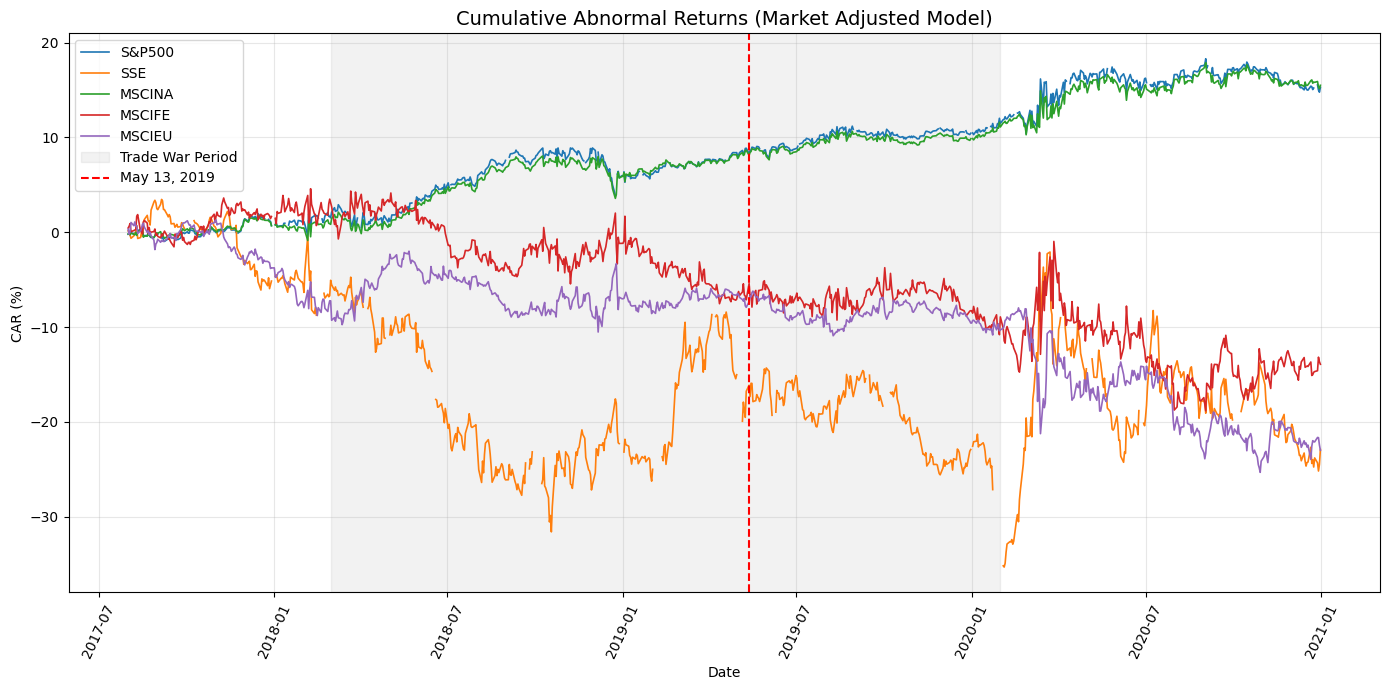

In [11]:
# Cell 9 — CAR Charts
smpl_start = date.fromisoformat('2017-08-01')
smpl_end = date.fromisoformat('2020-12-31')
smpl_mask = (returns.index >= smpl_start) & (returns.index <= smpl_end)
returns_smpl = returns.loc[smpl_mask]

fig, ax = plt.subplots(figsize=(14, 7))

for col in INDICES:
    ar = returns_smpl[col] - returns_smpl[BENCHMARK]
    car = ar.cumsum()
    ax.plot(car.index, car.values, label=col, linewidth=1.2)

ax.axvspan(
    pd.Timestamp('2018-03-01'), pd.Timestamp('2020-01-31'),
    alpha=0.1, color='gray', label='Trade War Period'
)
ax.axvline(
    pd.Timestamp('2019-05-13'),
    color='red', linestyle='--', linewidth=1.5, label='May 13, 2019'
)

ax.set_title('Cumulative Abnormal Returns (Market Adjusted Model)', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('CAR (%)')
ax.legend(loc='best', fontsize=10)
ax.tick_params(axis='x', rotation=65)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [12]:
# Cell 10 — GARCH Sub-Period Analysis
SUB_PERIODS = {
    'Pre-event': (date.fromisoformat('2017-08-01'), date.fromisoformat('2018-02-28')),
    'Event': (date.fromisoformat('2018-03-01'), date.fromisoformat('2020-01-31')),
}

print("=" * 60)
print("GARCH SUB-PERIOD ANALYSIS")
print("=" * 60)
print("Full model: AR(1)–AR(9) + GARCH(1,1)")
print("Refined model: significant AR lags only + GARCH(1,1)")

for col in INDICES:
    print(f"\n{'='*60}")
    print(f"INDEX: {col.upper()}")
    print(f"{'='*60}")

    for period_name, (p_start, p_end) in SUB_PERIODS.items():
        print(f"\n  --- {period_name} ({p_start} to {p_end}) ---")
        try:
            full_res, refined_res = fit_garch_subperiod(
                returns, col, p_start, p_end, max_ar_lags=9
            )
            print(f"\n  Full Model Summary:")
            print(full_res.summary().tables[1])
            print(f"\n  Refined Model Summary:")
            print(refined_res.summary().tables[1])
        except Exception as e:
            print(f"  GARCH estimation failed: {e}")

GARCH SUB-PERIOD ANALYSIS
Full model: AR(1)–AR(9) + GARCH(1,1)
Refined model: significant AR lags only + GARCH(1,1)

INDEX: S&P500

  --- Pre-event (2017-08-01 to 2018-02-28) ---

  Full Model Summary:
                                 Mean Model                                
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
Const          0.1318  4.840e-02      2.723  6.462e-03  [3.695e-02,  0.227]
S&P500[1]     -0.0574  8.851e-02     -0.649      0.516    [ -0.231,  0.116]
S&P500[2]     -0.0923      0.126     -0.732      0.464    [ -0.339,  0.155]
S&P500[3]      0.0360      0.113      0.319      0.750    [ -0.185,  0.257]
S&P500[4]     -0.0371      0.111     -0.334      0.738    [ -0.255,  0.181]
S&P500[5]      0.0835      0.110      0.762      0.446    [ -0.131,  0.298]
S&P500[6]      0.0666  7.541e-02      0.884      0.377 [-8.117e-02,  0.214]
S&P500[7]      0.1561  8.127e-02      

In [13]:
# Cell 11 — Export to Excel
import os

EXPORT_DIR = os.path.dirname(DATA_PATH)

all_tables = {}
all_tables.update(build_all_tables(results_am, 'AM'))
all_tables.update(build_all_tables(results_mm, 'MM'))
all_tables.update(build_all_tables(results_garch, 'GARCH'))

export_path = os.path.join(EXPORT_DIR, 'event_study_results.xlsx')
export_to_excel(all_tables, export_path)
print(f"Results exported to: {export_path}")

Exported 15 sheets to /content/drive/MyDrive/data/event_study_results.xlsx
Results exported to: /content/drive/MyDrive/data/event_study_results.xlsx
